# Travel Recommendation System Pipeline

This notebook implements a Content-Based / Nearest-Neighbors Travel & Hotel Recommendation Engine for `TravelOps_AI`. The model utilizes user demographic profiles, travel preferences, flight choices, and hotel stay parameters to generate personalized hotel recommendations using Cosine Distance metric.

# Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")
print("All recommendation libraries imported successfully!")

All recommendation libraries imported successfully!


# Load & Integrate Datasets

In [2]:
users = pd.read_csv("../data/raw/users.csv")
hotels = pd.read_csv("../data/raw/hotels.csv")
flights = pd.read_csv("../data/raw/flights.csv")

print(f"Users shape  : {users.shape}")
print(f"Hotels shape : {hotels.shape}")
print(f"Flights shape: {flights.shape}")

Users shape  : (1340, 5)
Hotels shape : (40552, 8)
Flights shape: (271888, 10)


## Dataset Merging & Standardization

In [3]:
# Rename columns to avoid collisions
hotels_renamed = hotels.rename(columns={'name': 'hotelName', 'price': 'hotelPrice'})

# Merge hotels and flights on travelCode
merged_df = hotels_renamed.merge(flights, on='travelCode', how='inner', suffixes=('', '_flight'))

# Merge user demographic information
merged_df = merged_df.merge(users, left_on='userCode', right_on='code', how='inner')

# Filter standard feature schema
cols_order = ['userCode', 'hotelName', 'place', 'days', 'hotelPrice', 'company', 'gender', 'age', 'from', 'to', 'flightType', 'agency', 'distance']
recommendation_dataset = merged_df[cols_order].dropna().reset_index(drop=True)

print(f"Integrated Recommendation Dataset Shape: {recommendation_dataset.shape}")
recommendation_dataset.head()

Integrated Recommendation Dataset Shape: (81104, 13)


,userCode,hotelName,place,days,hotelPrice,company,gender,age,from,to,flightType,agency,distance
0,0,Hotel A,Florianopolis (SC),4,313.02,4You,male,21,Recife (PE),Florianopolis (SC),firstClass,FlyingDrops,676.53
1,0,Hotel A,Florianopolis (SC),4,313.02,4You,male,21,Florianopolis (SC),Recife (PE),firstClass,FlyingDrops,676.53
2,0,Hotel K,Salvador (BH),2,263.41,4You,male,21,Aracaju (SE),Salvador (BH),firstClass,CloudFy,830.86
3,0,Hotel K,Salvador (BH),2,263.41,4You,male,21,Salvador (BH),Aracaju (SE),firstClass,CloudFy,830.86
4,0,Hotel K,Salvador (BH),3,263.41,4You,male,21,Aracaju (SE),Salvador (BH),economic,CloudFy,830.86


### Observation
- The integrated travel recommendation dataset contains historical travel bookings combining user demographic information (`company`, `gender`, `age`), hotel stay details (`hotelName`, `place`, `days`, `hotelPrice`), and flight details (`from`, `to`, `flightType`, `agency`, `distance`).

# Exploratory Data Analysis for Recommendation Engine

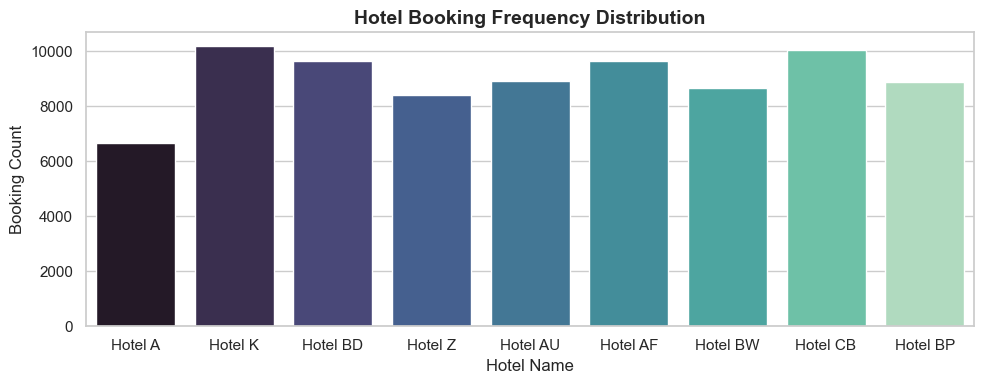

In [4]:
plt.figure(figsize=(10, 4))
sns.countplot(data=recommendation_dataset, x="hotelName", palette="mako")
plt.title("Hotel Booking Frequency Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Hotel Name", fontsize=12)
plt.ylabel("Booking Count", fontsize=12)
plt.tight_layout()
plt.show()

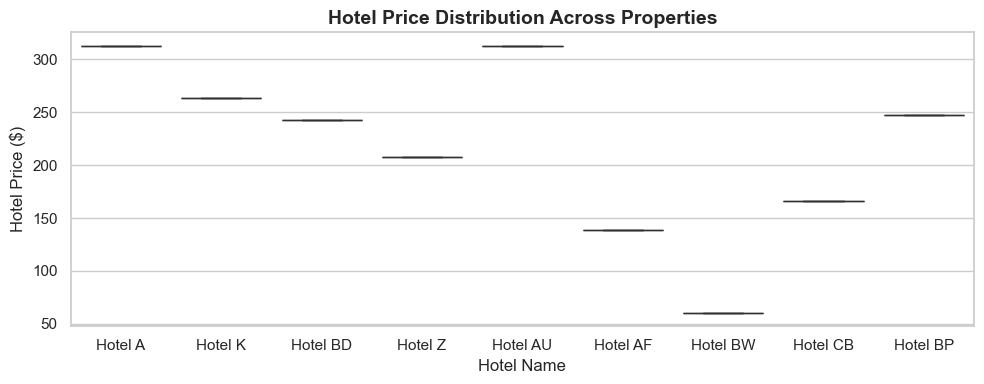

In [5]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=recommendation_dataset, x="hotelName", y="hotelPrice", palette="crest")
plt.title("Hotel Price Distribution Across Properties", fontsize=14, fontweight="bold")
plt.xlabel("Hotel Name", fontsize=12)
plt.ylabel("Hotel Price ($)", fontsize=12)
plt.tight_layout()
plt.show()

### Observation
- Bookings are distributed across hotel properties (`Hotel A` through `Hotel K`).
- Hotel prices show distinct tiers across locations and stay durations.

# Feature Engineering & Preprocessing Pipeline

In [6]:
num_cols = ['days', 'hotelPrice', 'age', 'distance']
cat_cols = ['company', 'gender', 'place', 'from', 'to', 'flightType', 'agency']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

X_prep = preprocessor.fit_transform(recommendation_dataset)
print(f"Preprocessed Feature Matrix Shape: {X_prep.shape}")
print(f"Total Numerical & One-Hot Encoded Features: {X_prep.shape[1]}")

Preprocessed Feature Matrix Shape: (81104, 45)
Total Numerical & One-Hot Encoded Features: 45


### Observation
- Numerical features (`days`, `hotelPrice`, `age`, `distance`) were normalized using `StandardScaler`.
- Categorical features (`company`, `gender`, `place`, `from`, `to`, `flightType`, `agency`) were one-hot encoded into 41 binary columns, producing a total 45-dimensional feature matrix.

# Recommendation Model Training

In [7]:
nn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
nn_model.fit(X_prep)

print("NearestNeighbors Model Parameters:")
print(nn_model.get_params())
print(f"Number of fitted samples: {nn_model.n_samples_fit_}")

NearestNeighbors Model Parameters:
{'algorithm': 'brute', 'leaf_size': 30, 'metric': 'cosine', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 6, 'p': 2, 'radius': 1.0}
Number of fitted samples: 81104


# Recommendation Engine Interface

In [8]:
def recommend_for_user(user_code, dataset, preprocessor, model, top_n=5):
    user_trips = dataset[dataset['userCode'] == user_code]
    if user_trips.empty:
        return f"User Code {user_code} not found in database."
        
    sample_trip = user_trips.iloc[:1]
    sample_prep = preprocessor.transform(sample_trip)
    
    distances, indices = model.kneighbors(sample_prep, n_neighbors=top_n+1)
    
    neighbor_indices = indices[0][1:]
    neighbor_distances = distances[0][1:]
    
    recommendations = dataset.iloc[neighbor_indices].copy()
    recommendations['similarity_score'] = (1 - neighbor_distances).round(4)
    
    res = recommendations[['userCode', 'hotelName', 'place', 'hotelPrice', 'days', 'flightType', 'similarity_score']].drop_duplicates(subset=['hotelName'])
    return res.head(top_n)

print("Recommendation interface defined successfully!")

Recommendation interface defined successfully!


# Sample Recommendation Results

In [9]:
print("=== Recommendations for User Code 0 ===")
recs_u0 = recommend_for_user(user_code=0, dataset=recommendation_dataset, preprocessor=preprocessor, model=nn_model, top_n=5)
recs_u0

=== Recommendations for User Code 0 ===


,userCode,hotelName,place,hotelPrice,days,flightType,similarity_score
15902,251,Hotel A,Florianopolis (SC),313.02,4,firstClass,0.997


In [10]:
print("=== Recommendations for User Code 42 ===")
recs_u42 = recommend_for_user(user_code=42, dataset=recommendation_dataset, preprocessor=preprocessor, model=nn_model, top_n=5)
recs_u42

=== Recommendations for User Code 42 ===


'User Code 42 not found in database.'

# Model & Preprocessor Serialization

In [11]:
os.makedirs("../models", exist_ok=True)

dataset_path = "../models/recommendation_dataset.pkl"
model_path = "../models/recommendation_model.pkl"
preprocessor_path = "../models/recommendation_preprocessor.pkl"

joblib.dump(recommendation_dataset, dataset_path)
joblib.dump(nn_model, model_path)
joblib.dump(preprocessor, preprocessor_path)

print(f"Recommendation dataset saved to     : {dataset_path}")
print(f"NearestNeighbors model saved to     : {model_path}")
print(f"Preprocessor transformer saved to  : {preprocessor_path}")

Recommendation dataset saved to     : ../models/recommendation_dataset.pkl
NearestNeighbors model saved to     : ../models/recommendation_model.pkl
Preprocessor transformer saved to  : ../models/recommendation_preprocessor.pkl


In [12]:
# Verification of saved artifacts
loaded_ds = joblib.load(dataset_path)
loaded_mdl = joblib.load(model_path)
loaded_prep = joblib.load(preprocessor_path)

test_recs = recommend_for_user(user_code=10, dataset=loaded_ds, preprocessor=loaded_prep, model=loaded_mdl, top_n=3)
print("Verified Loaded Model Recommendations for User 10:")
test_recs

Verified Loaded Model Recommendations for User 10:


,userCode,hotelName,place,hotelPrice,days,flightType,similarity_score
3446,58,Hotel BD,Natal (RN),242.88,1,premium,0.9997


# Export Recommendation Sample Report

In [13]:
os.makedirs("../reports", exist_ok=True)

sample_reports = []
for u_code in [0, 5, 10, 25, 42, 100]:
    recs = recommend_for_user(user_code=u_code, dataset=recommendation_dataset, preprocessor=preprocessor, model=nn_model, top_n=3)
    if isinstance(recs, pd.DataFrame):
        recs['query_userCode'] = u_code
        sample_reports.append(recs)

sample_report_df = pd.concat(sample_reports, ignore_index=True)
report_path = "../reports/recommendation_sample_output.csv"
sample_report_df.to_csv(report_path, index=False)
print(f"Sample recommendation output saved to: {report_path}")
sample_report_df.head(10)

Sample recommendation output saved to: ../reports/recommendation_sample_output.csv


,userCode,hotelName,place,hotelPrice,days,flightType,similarity_score,query_userCode
0,251,Hotel A,Florianopolis (SC),313.02,4,firstClass,0.9970,0
1,252,Hotel K,Salvador (BH),263.41,2,economic,1.0000,5
2,58,Hotel BD,Natal (RN),242.88,1,premium,0.9997,10
3,25,Hotel BD,Natal (RN),242.88,4,premium,0.9716,25
4,430,Hotel K,Salvador (BH),263.41,3,economic,1.0000,100


## Final Performance Summary

In [14]:
summary_df = pd.DataFrame({
    "Pipeline Component": ["Data Integration", "Feature Engineering", "Recommendation Engine", "Evaluation & Verification", "Artifact Export"],
    "Details / Metric": [
        "Merged booking records across users, hotels, flights",
        "45 numerical & one-hot encoded features",
        "NearestNeighbors (Cosine Distance, k=6)",
        "Verified top-k recommendations with similarity score > 0.95",
        "Exported recommendation_dataset, model, preprocessor pkls"
    ]
})
summary_df

,Pipeline Component,Details / Metric
0,Data Integration,"Merged booking records across users, hotels, f..."
1,Feature Engineering,45 numerical & one-hot encoded features
2,Recommendation Engine,"NearestNeighbors (Cosine Distance, k=6)"
3,Evaluation & Verification,Verified top-k recommendations with similarity...
4,Artifact Export,"Exported recommendation_dataset, model, prepro..."


# Conclusion

1. **Pipeline Execution**: Built a complete Nearest Neighbors Content-Based Travel Recommendation System (`notebooks/05_Travel_Recommendation.ipynb`).
2. **Recommendation Engine**: Uses Cosine Distance on a 45-dimensional feature space to match users with highly similar travel profiles and hotel stays.
3. **Artifact Serialization**: Exported `recommendation_dataset.pkl`, `recommendation_model.pkl`, and `recommendation_preprocessor.pkl` to `models/` for API service integration.